# 1... Importing data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
data = pd.read_csv('final_df.csv')
#data = pd.read_csv('Oversampled_df.csv')
#data = pd.read_csv('downsampled_df.csv')
data.set_index('date', inplace=True)
data.head()

,Close_^DJI,Close_^FCHI,Close_^FTSE,Close_^GDAXI,Close_^GSPTSE,Close_^HSI,Close_^IXIC,Close_^N225,Volume_^DJI,Volume_^FCHI,...,WBAA_pct_change,DPSACBW027SBOG_pct_change,WCOILWTICO_pct_change,WGS30YR_pct_change,WRESBAL_pct_change,WGS20YR_pct_change,MORTGAGE15US_pct_change,WPRIME_pct_change,CCSA_pct_change,TOTCI_pct_change
date,,,,,,,,,,,,,,,,,,,,,
1992-01-06,3200.100098,1787.599976,2493.199951,1604.689941,3524.800049,4307.000000,597.900024,23801.179688,27280000.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1992-01-13,3185.600098,1824.300049,2490.100098,1620.449951,3594.399902,4325.899902,617.630005,21696.859375,19300000.0,0.0,...,-0.658617,0.606685,-3.663004,-0.268456,-0.170401,0.0,0.000000,0.0,-1.994135,-0.129018
1992-01-20,3254.000000,1865.900024,2544.899902,1685.140015,3655.699951,4510.500000,619.380005,20913.820312,18190000.0,0.0,...,0.662983,0.629639,2.172732,1.884253,-6.181224,0.0,3.080873,0.0,-1.346499,0.082590
1992-01-27,3240.600098,1869.300049,2539.899902,1686.709961,3628.500000,4554.700195,621.000000,21007.109375,19110000.0,0.0,...,0.548847,0.102548,-0.797448,1.056803,2.469709,0.0,1.369863,0.0,2.032150,-0.299896
1992-02-03,3234.100098,1857.000000,2560.199951,1685.660034,3594.399902,4672.100098,623.429993,22139.589844,18860000.0,0.0,...,0.436681,-0.222724,2.090032,1.176471,-17.226399,0.0,1.719902,0.0,-1.872771,-0.013167


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1712 entries, 1992-01-06 to 2024-10-21
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Close_^DJI                 1712 non-null   float64
 1   Close_^FCHI                1712 non-null   float64
 2   Close_^FTSE                1712 non-null   float64
 3   Close_^GDAXI               1712 non-null   float64
 4   Close_^GSPTSE              1712 non-null   float64
 5   Close_^HSI                 1712 non-null   float64
 6   Close_^IXIC                1712 non-null   float64
 7   Close_^N225                1712 non-null   float64
 8   Volume_^DJI                1712 non-null   float64
 9   Volume_^FCHI               1712 non-null   float64
 10  Volume_^FTSE               1712 non-null   float64
 11  Volume_^GDAXI              1712 non-null   float64
 12  Volume_^GSPTSE             1712 non-null   float64
 13  Volume_^HSI                1712 non-nu

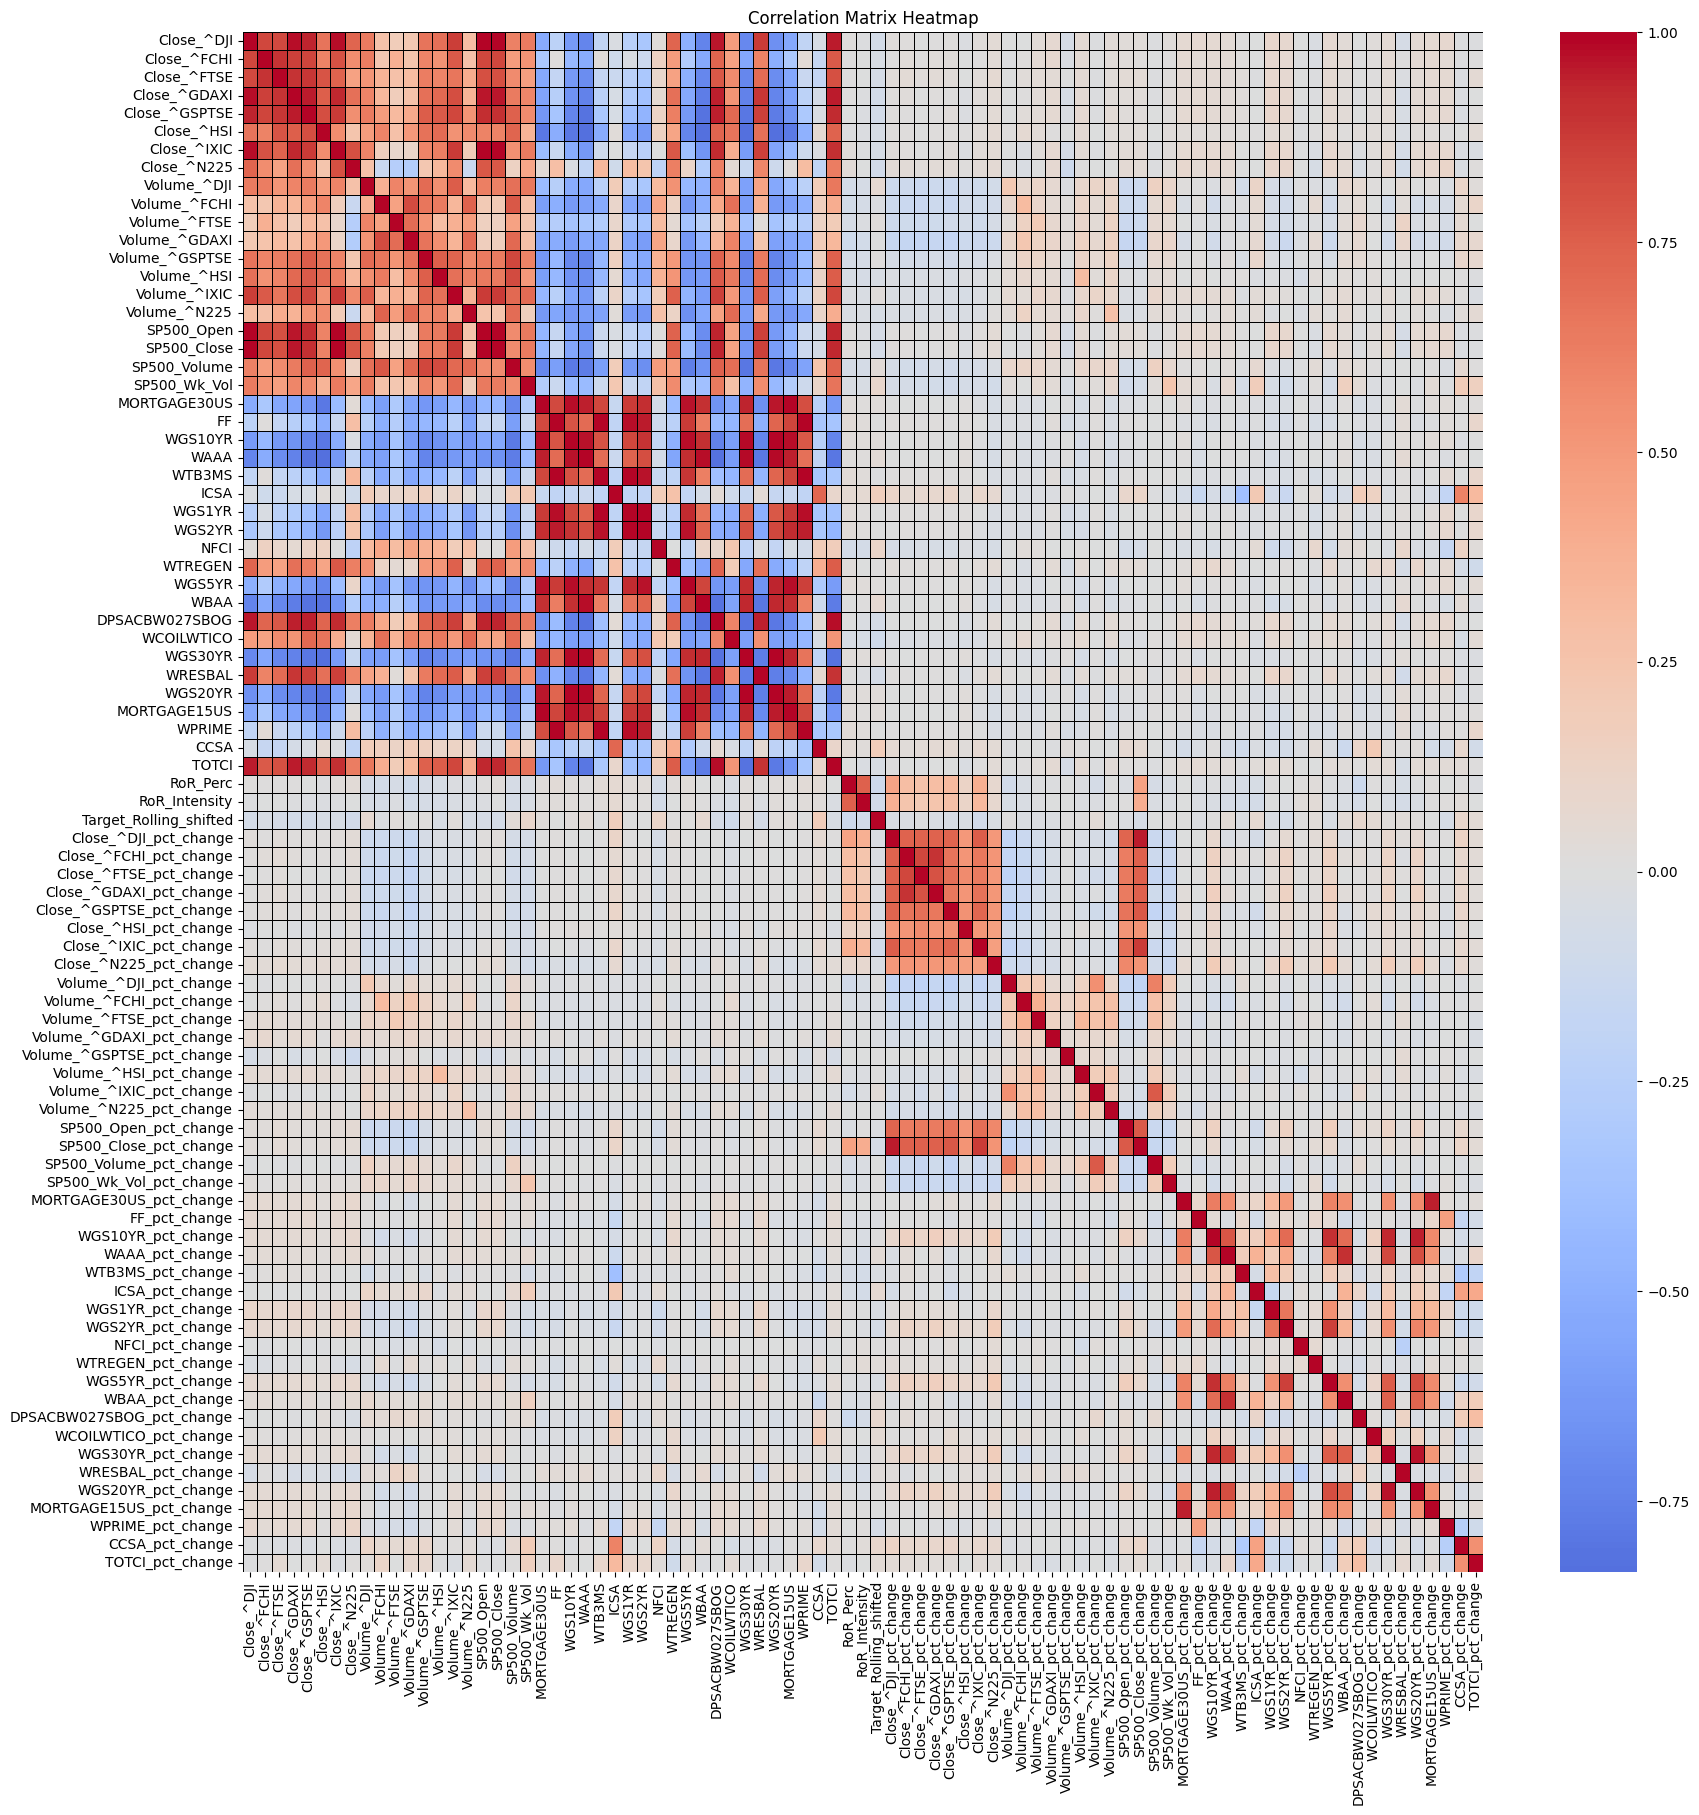

In [4]:
data_corr = data.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(data_corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5, linecolor='black')
plt.title('Correlation Matrix Heatmap')
plt.show()

# 2... Models

In [5]:
# Importing libraries
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from keras.utils import to_categorical



## 2.1... Using original values

In [6]:
data_trial1 = data.iloc[:, list(range(0, 44))]
data_trial1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1712 entries, 1992-01-06 to 2024-10-21
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Close_^DJI              1712 non-null   float64
 1   Close_^FCHI             1712 non-null   float64
 2   Close_^FTSE             1712 non-null   float64
 3   Close_^GDAXI            1712 non-null   float64
 4   Close_^GSPTSE           1712 non-null   float64
 5   Close_^HSI              1712 non-null   float64
 6   Close_^IXIC             1712 non-null   float64
 7   Close_^N225             1712 non-null   float64
 8   Volume_^DJI             1712 non-null   float64
 9   Volume_^FCHI            1712 non-null   float64
 10  Volume_^FTSE            1712 non-null   float64
 11  Volume_^GDAXI           1712 non-null   float64
 12  Volume_^GSPTSE          1712 non-null   float64
 13  Volume_^HSI             1712 non-null   float64
 14  Volume_^IXIC            1712 n

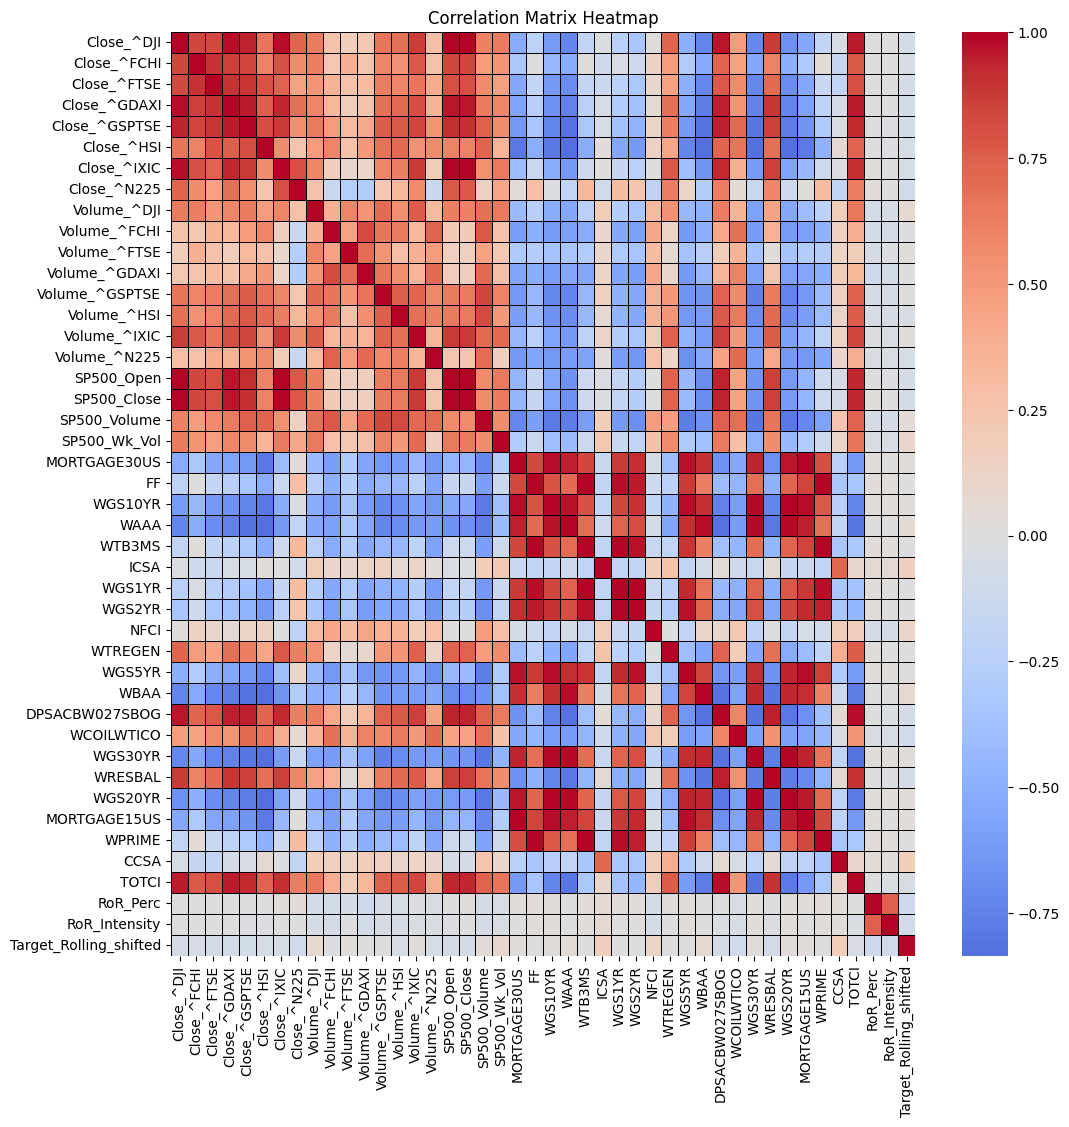

In [7]:
datat1_corr = data_trial1.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(datat1_corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5, linecolor='black')
plt.title('Correlation Matrix Heatmap')
plt.show()

We are going to evaluate 2 different target variables, the 5 label encoding for RoR Intensity week by week, and the binary classification for the high RoR summatory of the last 5 weeks (shifted to the start of the window).

### 2.1.1... RoR Rolling 5

#### Neural Network

In [8]:
data_trial1_2lab = data_trial1.drop(['SP500_Open', 'RoR_Perc', 'RoR_Intensity'], axis=1)

In [9]:
X2 = data_trial1_2lab.drop('Target_Rolling_shifted', axis=1)
y2 = data_trial1_2lab['Target_Rolling_shifted']

print(X2.shape)
print(y2.shape)

(1712, 40)
(1712,)


In [10]:
scaler2 = StandardScaler()

X2_scaled = scaler2.fit_transform(X2)

In [11]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size = 0.3)
print(X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape)

(1198, 40) (514, 40) (1198,) (514,)


In [12]:
y2_train = to_categorical(y2_train)
y2_test = to_categorical(y2_test)

In [13]:
# Building the model
model2 = Sequential()

model2.add(Input(shape=(X2_train.shape[1],)))
model2.add(Dense(128, activation='relu'))
#model.add(Dropout(0.25))
model2.add(Dense(64, activation='relu'))
#model.add(Dropout(0.25))

model2.add(Dense(2, activation='softmax'))

In [14]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,634 (53.26 KB)

 Trainable params: 13,634 (53.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model2.compile(optimizer=Adam(learning_rate=0.001), loss='crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [16]:
history2 = model2.fit(X2_train, y2_train, epochs=256, batch_size=256, verbose=1,
                      validation_data=(X2_test, y2_test))

Epoch 1/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4665 - loss: 0.8041 - precision: 0.4665 - recall: 0.4665 - val_accuracy: 0.8891 - val_loss: 0.4264 - val_precision: 0.8891 - val_recall: 0.8891
Epoch 2/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8701 - loss: 0.4270 - precision: 0.8701 - recall: 0.8701 - val_accuracy: 0.9047 - val_loss: 0.3444 - val_precision: 0.9047 - val_recall: 0.9047
Epoch 3/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8762 - loss: 0.4009 - precision: 0.8762 - recall: 0.8762 - val_accuracy: 0.9047 - val_loss: 0.3181 - val_precision: 0.9047 - val_recall: 0.9047
Epoch 4/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8825 - loss: 0.3870 - precision: 0.8825 - recall: 0.8825 - val_accuracy: 0.9047 - val_loss: 0.2936 - val_precision: 0.9047 - val_recall: 0.9047
Epoch 5/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8733 - loss: 0.3764 - precision: 0.8733 - recall: 0.8733 - val_accuracy: 0.9066 - val_loss: 0.2917 - val_pre

In [17]:
# Evaluating the model on test data
test_loss, test_accuracy, test_precision, test_recall = model2.evaluate(X2_test, y2_test, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.8803 - loss: 0.4258 - precision: 0.8803 - recall: 0.8803
Test Accuracy: 0.8755
Test Precision: 0.8755
Test Recall: 0.8755


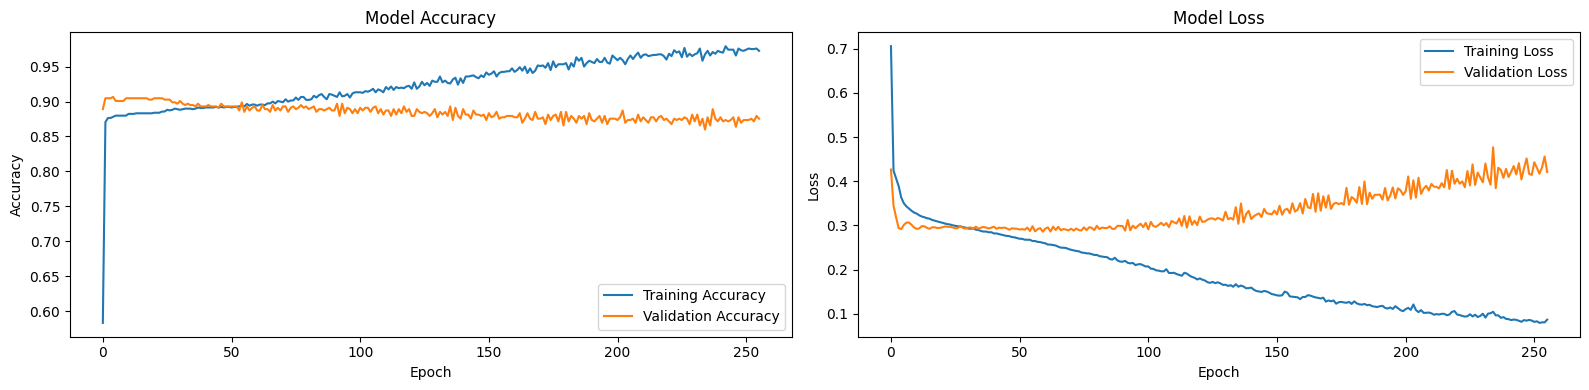

In [18]:
# Plotting training and validation accuracy values
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plotting training and validation loss values
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

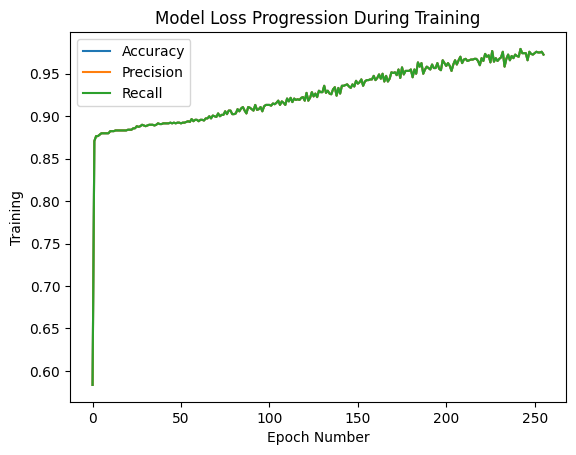

In [19]:
plt.plot(history2.history['accuracy'], label='Accuracy')
plt.plot(history2.history['precision'], label='Precision')
plt.plot(history2.history['recall'], label='Recall')

plt.title('Model Loss Progression During Training')
plt.ylabel('Training')
plt.xlabel('Epoch Number')
plt.legend(['Accuracy', 'Precision', 'Recall'])

#### Random Forest

In [20]:
# Convert to flattened categorical variable
y2_train_flat = np.argmax(y2_train, axis=1)
print(y2_train_flat)

y2_test_flat = np.argmax(y2_test, axis=1)

[0 1 0 ... 0 0 0]


In [21]:
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=10)

rfc.fit(X2_train, y2_train_flat)

y_pred=rfc.predict(X2_test)

print("Accuracy:",metrics.accuracy_score(y2_test_flat, y_pred))
print("Precision:", metrics.precision_score(y2_test_flat, y_pred, average='weighted'))
print("Recall:", metrics.recall_score(y2_test_flat, y_pred, average='weighted'))

Accuracy: 0.896887159533074
Precision: 0.8786897985872164
Recall: 0.896887159533074


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y2_test_flat, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       465
           1       0.43      0.27      0.33        49

    accuracy                           0.90       514
   macro avg       0.68      0.61      0.64       514
weighted avg       0.88      0.90      0.89       514



<Axes: xlabel='Predicted', ylabel='Actual'>

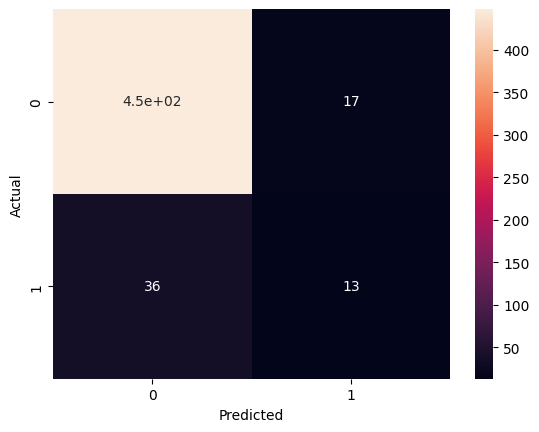

In [23]:
cm = pd.crosstab(y2_test_flat, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm, annot=True)

#### XGB Classifier

In [24]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=10)

xgb_model.fit(X2_train, y2_train_flat)

y_pred1 = xgb_model.predict(X2_test)

print("Accuracy:", metrics.accuracy_score(y2_test_flat, y_pred1))
print("Precision:", metrics.precision_score(y2_test_flat, y_pred1, average='weighted'))
print("Recall:", metrics.recall_score(y2_test_flat, y_pred1, average='weighted'))

Accuracy: 0.9007782101167315
Precision: 0.8762898271890396
Recall: 0.9007782101167315


In [25]:
print(classification_report(y2_test_flat, y_pred1))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       465
           1       0.45      0.20      0.28        49

    accuracy                           0.90       514
   macro avg       0.69      0.59      0.61       514
weighted avg       0.88      0.90      0.88       514



<Axes: xlabel='Predicted', ylabel='Actual'>

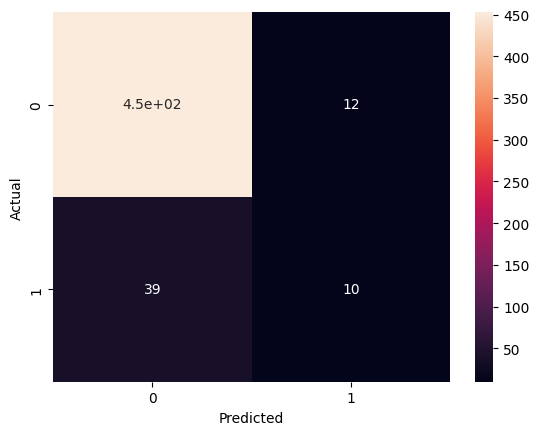

In [26]:
cm1 = pd.crosstab(y2_test_flat, y_pred1, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm1, annot=True)

#### SVM

In [27]:
from sklearn.svm import SVC

svm_model2 = SVC()

svm_model2.fit(X2_train, y2_train_flat)

y_pred2 = svm_model2.predict(X2_test)

print("Accuracy:", metrics.accuracy_score(y2_test_flat, y_pred2))
print("Precision:", metrics.precision_score(y2_test_flat, y_pred2, average='weighted'))
print("Recall:", metrics.recall_score(y2_test_flat, y_pred2, average='weighted'))

Accuracy: 0.9066147859922179
Precision: 0.8850147595950059
Recall: 0.9066147859922179


In [28]:
print(classification_report(y2_test_flat, y_pred2))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       465
           1       0.67      0.04      0.08        49

    accuracy                           0.91       514
   macro avg       0.79      0.52      0.51       514
weighted avg       0.89      0.91      0.87       514



<Axes: xlabel='Predicted', ylabel='Actual'>

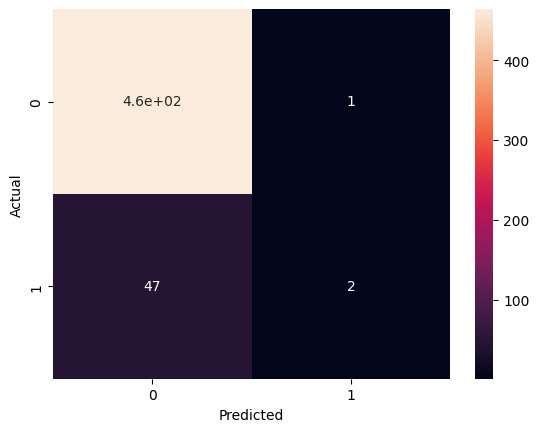

In [29]:
cm2 = pd.crosstab(y2_test_flat, y_pred2, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm2, annot=True)

### 2.1.2... RoR Intensity

#### Neural Network

In [30]:
data_trial1_5lab = data_trial1.drop(['SP500_Open', 'RoR_Perc', 'Target_Rolling_shifted'], axis=1)

In [31]:
X1 = data_trial1_5lab.drop('RoR_Intensity', axis=1)
y1 = data_trial1_5lab['RoR_Intensity']

print(X1.shape)
print(y1.shape)

(1712, 40)
(1712,)


In [32]:
scaler = StandardScaler()

X1_scaled = scaler.fit_transform(X1)

In [33]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y1, test_size = 0.3)
print(X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape)

(1198, 40) (514, 40) (1198,) (514,)


In [34]:
y1_train = to_categorical(y1_train)
y1_test = to_categorical(y1_test)

In [35]:
# Building the model
model = Sequential()

model.add(Input(shape=(X1_train.shape[1],)))
model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
#model.add(Dropout(0.25))

model.add(Dense(3, activation='softmax'))

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,699 (53.51 KB)

 Trainable params: 13,699 (53.51 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer=Adam(learning_rate=0.00001), loss='crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [38]:
history = model.fit(X1_train, y1_train, epochs=256, batch_size=256, verbose=1,
                      validation_data=(X1_test, y1_test))

Epoch 1/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4326 - loss: 1.0885 - precision: 0.7556 - recall: 0.1400 - val_accuracy: 0.4689 - val_loss: 1.0695 - val_precision: 0.7658 - val_recall: 0.1654
Epoch 2/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4403 - loss: 1.0760 - precision: 0.7676 - recall: 0.1518 - val_accuracy: 0.4689 - val_loss: 1.0613 - val_precision: 0.7818 - val_recall: 0.1673
Epoch 3/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4413 - loss: 1.0671 - precision: 0.7881 - recall: 0.1626 - val_accuracy: 0.4689 - val_loss: 1.0531 - val_precision: 0.8000 - val_recall: 0.1712
Epoch 4/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4499 - loss: 1.0647 - precision: 0.8206 - recall: 0.1656 - val_accuracy: 0.4747 - val_loss: 1.0450 - val_precision: 0.8257 - val_recall: 0.1751
Epoch 5/256
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4516 - loss: 1.0474 - precision: 0.8469 - recall: 0.1773 - val_accuracy: 0.4767 - val_loss: 1.0370 - val_pre

In [39]:
# Evaluating the model on test data
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X1_test, y1_test, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8820 - loss: 0.4397 - precision: 0.8820 - recall: 0.8820 
Test Accuracy: 0.8930
Test Precision: 0.8930
Test Recall: 0.8930


In [40]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


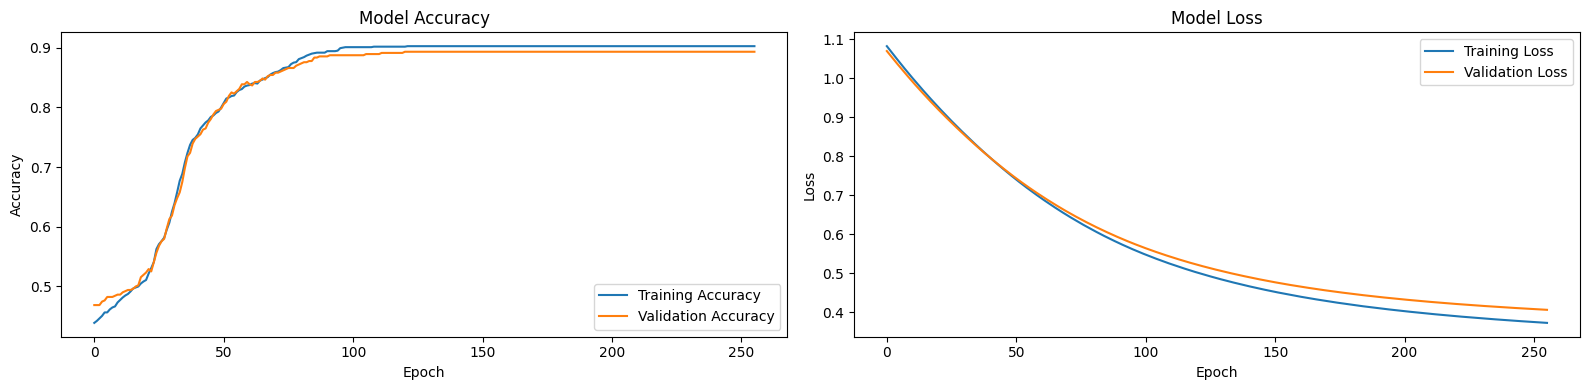

In [41]:
# Plotting training and validation accuracy values
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plotting training and validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

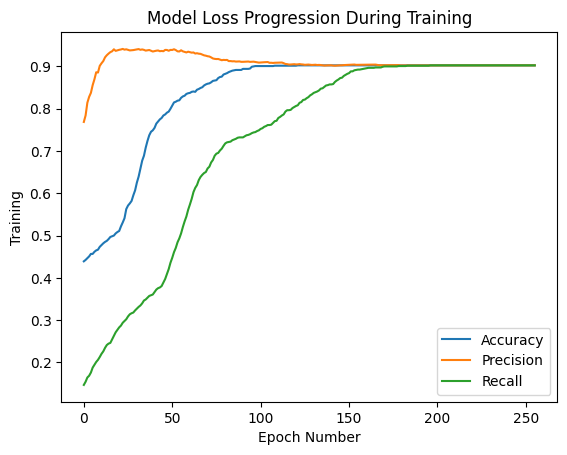

In [42]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['recall'], label='Recall')

plt.title('Model Loss Progression During Training')
plt.ylabel('Training')
plt.xlabel('Epoch Number')
plt.legend(['Accuracy', 'Precision', 'Recall'])

#### Random Forrest

In [43]:
# Convert to flattened categorical variable
y1_train_flat = np.argmax(y1_train, axis=1)

y1_test_flat = np.argmax(y1_test, axis=1)

[1 1 1 ... 1 1 1]
[1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 0 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 0 1 1 1 1 0 1 1 1 1 2 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 0 1 1 0 1 1 1
 1 1 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 2 1 1 1 1 0 1 1 1 1 2 1 1 1 1 1 1 1 2 1 0 1 1 1 1 1 1 0
 0 1 1 1 1 1 0 1 1 1 2 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 1 2 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 2 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1
 2 1 1 1 1 1 0 1 1 1 1 1 2 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 

In [44]:
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=10)

rfc.fit(X1_train, y1_train_flat)

y_pred3=rfc.predict(X1_test)

print("Accuracy:",metrics.accuracy_score(y1_test_flat, y_pred3))
print("Precision:", metrics.precision_score(y1_test_flat, y_pred3, average='weighted'))
print("Recall:", metrics.recall_score(y1_test_flat, y_pred3, average='weighted'))

Accuracy: 0.8891050583657587
Precision: 0.8238134625690253
Recall: 0.8891050583657587


In [45]:
from sklearn.metrics import classification_report
print(classification_report(y1_test_flat, y_pred3))

              precision    recall  f1-score   support

           0       0.25      0.10      0.14        30
           1       0.91      0.99      0.95       459
           2       0.00      0.00      0.00        25

    accuracy                           0.89       514
   macro avg       0.39      0.36      0.36       514
weighted avg       0.82      0.89      0.85       514



<Axes: xlabel='Predicted', ylabel='Actual'>

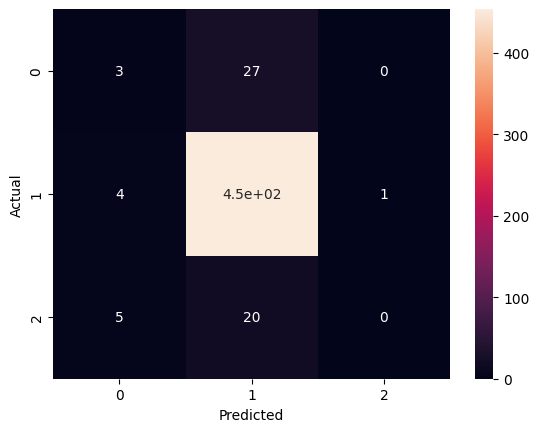

In [46]:
from sklearn.metrics import confusion_matrix
cm3 = pd.crosstab(y1_test_flat, y_pred3, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm3, annot=True)

#### XGB Classifier


In [47]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=10)

xgb_model.fit(X1_train, y1_train_flat)

y_pred4 = xgb_model.predict(X1_test)

print("Accuracy:", metrics.accuracy_score(y1_test_flat, y_pred4))
print("Precision:", metrics.precision_score(y1_test_flat, y_pred4, average='weighted'))
print("Recall:", metrics.recall_score(y1_test_flat, y_pred4, average='weighted'))


Accuracy: 0.8949416342412452
Precision: 0.8445196423865406
Recall: 0.8949416342412452


In [48]:
print(classification_report(y1_test_flat, y_pred4))

              precision    recall  f1-score   support

           0       0.57      0.13      0.22        30
           1       0.91      0.99      0.95       459
           2       0.00      0.00      0.00        25

    accuracy                           0.89       514
   macro avg       0.49      0.38      0.39       514
weighted avg       0.84      0.89      0.86       514



<Axes: xlabel='Predicted', ylabel='Actual'>

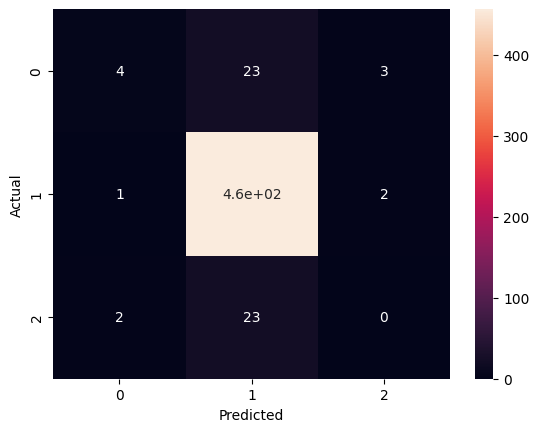

In [49]:
cm4 = pd.crosstab(y1_test_flat, y_pred4, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm4, annot=True)

#### SVM

In [50]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X1_train, y1_train_flat)

y_pred5 = svm_model.predict(X1_test)

print("Accuracy:", metrics.accuracy_score(y1_test_flat, y_pred5))
print("Precision:", metrics.precision_score(y1_test_flat, y_pred5, average='weighted'))
print("Recall:", metrics.recall_score(y1_test_flat, y_pred5, average='weighted'))


Accuracy: 0.8949416342412452
Precision: 0.8573622772885521
Recall: 0.8949416342412452


c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
print(classification_report(y1_test_flat, y_pred5))

              precision    recall  f1-score   support

           0       1.00      0.03      0.06        30
           1       0.89      1.00      0.94       459
           2       0.00      0.00      0.00        25

    accuracy                           0.89       514
   macro avg       0.63      0.34      0.34       514
weighted avg       0.86      0.89      0.85       514



c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

<Axes: xlabel='Predicted', ylabel='Actual'>

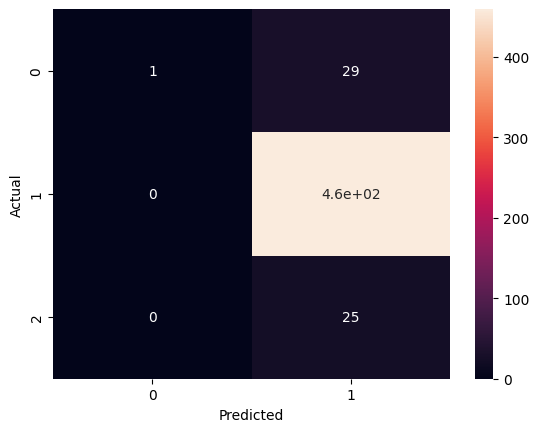

In [52]:
cm5 = pd.crosstab(y1_test_flat, y_pred5, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm5, annot=True)

# 3... Plotting

In [76]:
import matplotlib.dates as mdates

data_plot = pd.read_csv('final_df.csv')
#data_plot.info()

data_plot = data_plot.iloc[:, [0, 17, 18, 43, 44]]

data_plot['date'] = pd.to_datetime(data_plot['date'])

data_plot.head()


,date,SP500_Open,SP500_Close,RoR_Intensity,Target_Rolling_shifted
0,1992-01-06,419.309998,417.959991,1,0.0
1,1992-01-13,415.049988,414.339996,1,0.0
2,1992-01-20,418.859985,416.359985,1,0.0
3,1992-01-27,415.440002,414.989990,1,0.0
4,1992-02-03,408.790009,409.529999,1,0.0


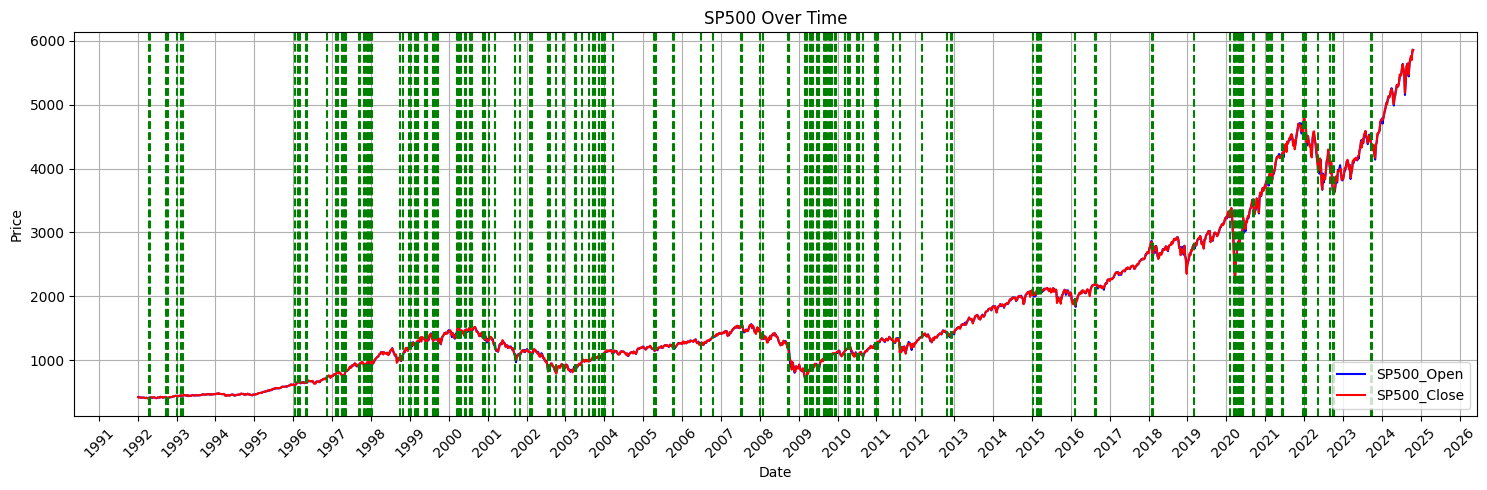

In [77]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(15, 5))

# Plot the first time series (SP500 Open)
ax.plot(data_plot['date'], data_plot['SP500_Open'], label='SP500_Open', color='blue')

# Plot the second time series (SP500 Close)
ax.plot(data_plot['date'], data_plot['SP500_Close'], label='SP500_Close', color='red')

# Add title and labels
ax.set_title('SP500 Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Price')

# Set the major date format to show only year and month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Set the major locator to show ticks at the beginning of each month
ax.xaxis.set_major_locator(mdates.YearLocator())  # Change interval for less frequent ticks

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Add a vertical line at a specific date (for example: '2024-10-15')
for index, item in data_plot.iterrows():
    if item['Target_Rolling_shifted'] == 1:
        ax.axvline(pd.to_datetime(item['date']), color='green', linestyle='--')

# Add a grid
ax.grid(True)

# Add a legend to differentiate the time series
ax.legend()

# Automatically adjust the layout to fit the x-axis labels
plt.tight_layout()

# Display the plot
plt.show()

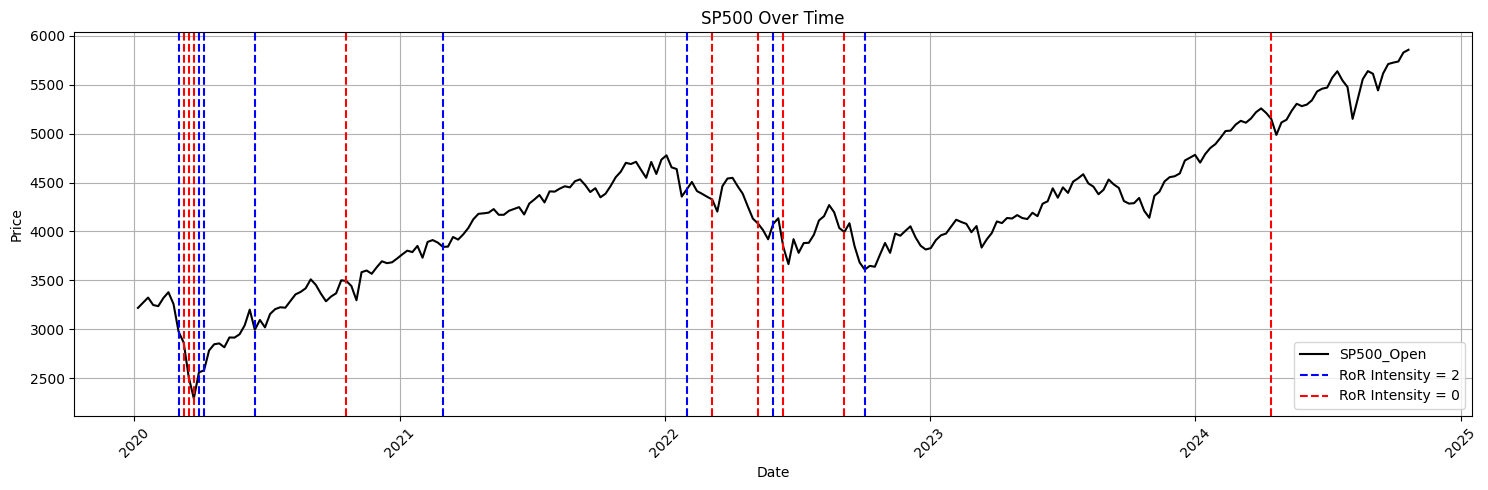

In [88]:
# Subset data
data_plot_subset = data_plot[data_plot['date'] > '2020-01-01']

# Create a figure and axis
fig, ax = plt.subplots(figsize=(15, 5))

# Plot the first time series (SP500 Open)
ax.plot(data_plot_subset['date'], data_plot_subset['SP500_Open'], label='SP500_Open', color='black')

# Add title and labels
ax.set_title('SP500 Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Price')

# Set the major date format to show only year and month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Set the major locator to show ticks at the beginning of each year
ax.xaxis.set_major_locator(mdates.YearLocator())

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Initialize flags to track if the legend labels for vertical lines have been added
red_label_added = False
blue_label_added = False

# Add vertical lines conditionally
for index, item in data_plot_subset.iterrows():
    if item['RoR_Intensity'] == 0 and not red_label_added:
        ax.axvline(pd.to_datetime(item['date']), color='red', linestyle='--', label='RoR Intensity = 0')
        red_label_added = True  # Ensures the label is only added once
    elif item['RoR_Intensity'] == 0:
        ax.axvline(pd.to_datetime(item['date']), color='red', linestyle='--')

    if item['RoR_Intensity'] == 2 and not blue_label_added:
        ax.axvline(pd.to_datetime(item['date']), color='blue', linestyle='--', label='RoR Intensity = 2')
        blue_label_added = True  # Ensures the label is only added once
    elif item['RoR_Intensity'] == 2:
        ax.axvline(pd.to_datetime(item['date']), color='blue', linestyle='--')

# Add a grid
ax.grid(True)

# Add a legend to differentiate the time series and vertical lines
ax.legend()

# Automatically adjust the layout to fit the x-axis labels
plt.tight_layout()

# Display the plot
plt.show()
